# Car Price Prediction


#### Project Workflow
1. Understand the Dataset
- Review all columns and their meanings (you’ve already done this — great start!)
- Identify which variables are:
- Independent (features)
- Dependent (target)

2. Clean and Prepare the Data
- Check for missing values or anomalies (e.g., nulls sales)
- Create new features if needed:

3. Explore the Data (EDA)
Use visualizations to uncover patterns:
- 📉 Boxplots to see sales distribution by weather or promotion
- 📌 Correlation heatmap to see which features influence sales most

4. Model Sales Drivers
- Use regression models (e.g., Linear Regression, Random Forest, XGBoost) to predict daily_sales
- Evaluate feature importance: which variables drive sales the most?
- Try time series models (e.g., ARIMA, Prophet) if you're forecasting future sales

7. Present Your Work
- Create a dashboard (Excel, Power BI, or Tableau)
- Summarize key insights in a slide deck or report
- Include visuals, trends, and actionable takeaways


In [1]:
# Importing Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
#Importing Dataset
df = pd.read_csv('car_sales_data.csv')

raw_df = df.copy()

## Data Cleaning

In [3]:
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [5]:
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


In [6]:
df.duplicated().sum()

12

In [7]:
df[df.duplicated()]

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
5426,VW,Polo,1.2,Petrol,2003,10000,8024
9862,Ford,Mondeo,1.4,Diesel,1987,224569,883
14745,BMW,Z4,2.4,Petrol,1999,12000,13410
19020,Toyota,Yaris,1.0,Petrol,1996,13500,5087
19337,VW,Polo,1.0,Petrol,2000,11500,5950
23927,VW,Polo,1.2,Petrol,2021,1000,27901
25368,VW,Golf,1.2,Diesel,2011,6000,17401
28576,VW,Polo,1.2,Petrol,2003,10000,8024
34246,VW,Passat,2.0,Diesel,2003,10000,16087
35647,Ford,Focus,1.6,Petrol,2019,2000,39636


In [8]:
# Handling Duplicates
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

0

In [10]:
df = df.reset_index(drop=True)

In [11]:
# Handling Missing Values
df.isnull().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

## EDA


✅ 1. Univariate Analysis (Quick Checks)
✔ Histograms / KDE plots for:
- Price
- Mileage
- Year of manufacture
- Engine size


✅ 2. Outlier Detection (Outliers can ruin models if not handled.)
Use: Boxplots, IQR, Scatterplots of Price vs key features
Look specifically for:
- Extremely old cars
- Very high mileage cars
- Price values too low or too high compared to the rest


✅ 3. Relationship Analysis (Minimal Pairwise Checks)
Only 3 scatterplots are needed:
- Price vs Mileage (declining trend?)
- Price vs Age/Year (strong expected relationship)
- Price vs Engine size (positive relationship)
Purpose:
Helps you see whether linear or non-linear models might work better, and where transformations may help.


✅ 4. Categorical Variable Insights
✔ View counts of: Manufacturer, Model, Fuel type
`df['Manufacturer'].value_counts()`
`df['Model'].value_counts()`
`df['Fuel type'].value_counts()`

Why this matters:
- Helps detect rare categories
- Helps decide which encoding to use
- Model will likely need target/frequency encoding
- Manufacturer/Fuel type → one-hot is fine


✅ 5. Multicollinearity Check (Optional but Recommended)

Mainly to avoid redundant variables:

- Year vs Car age (if you eventually create it)
- Engine size vs Engine category
- Mileage vs Mileage per year (after engineering)

For now, just check correlation among numerical columns


`NB: Do No7 after Completing Data Preprocessing and Feature Engineering`

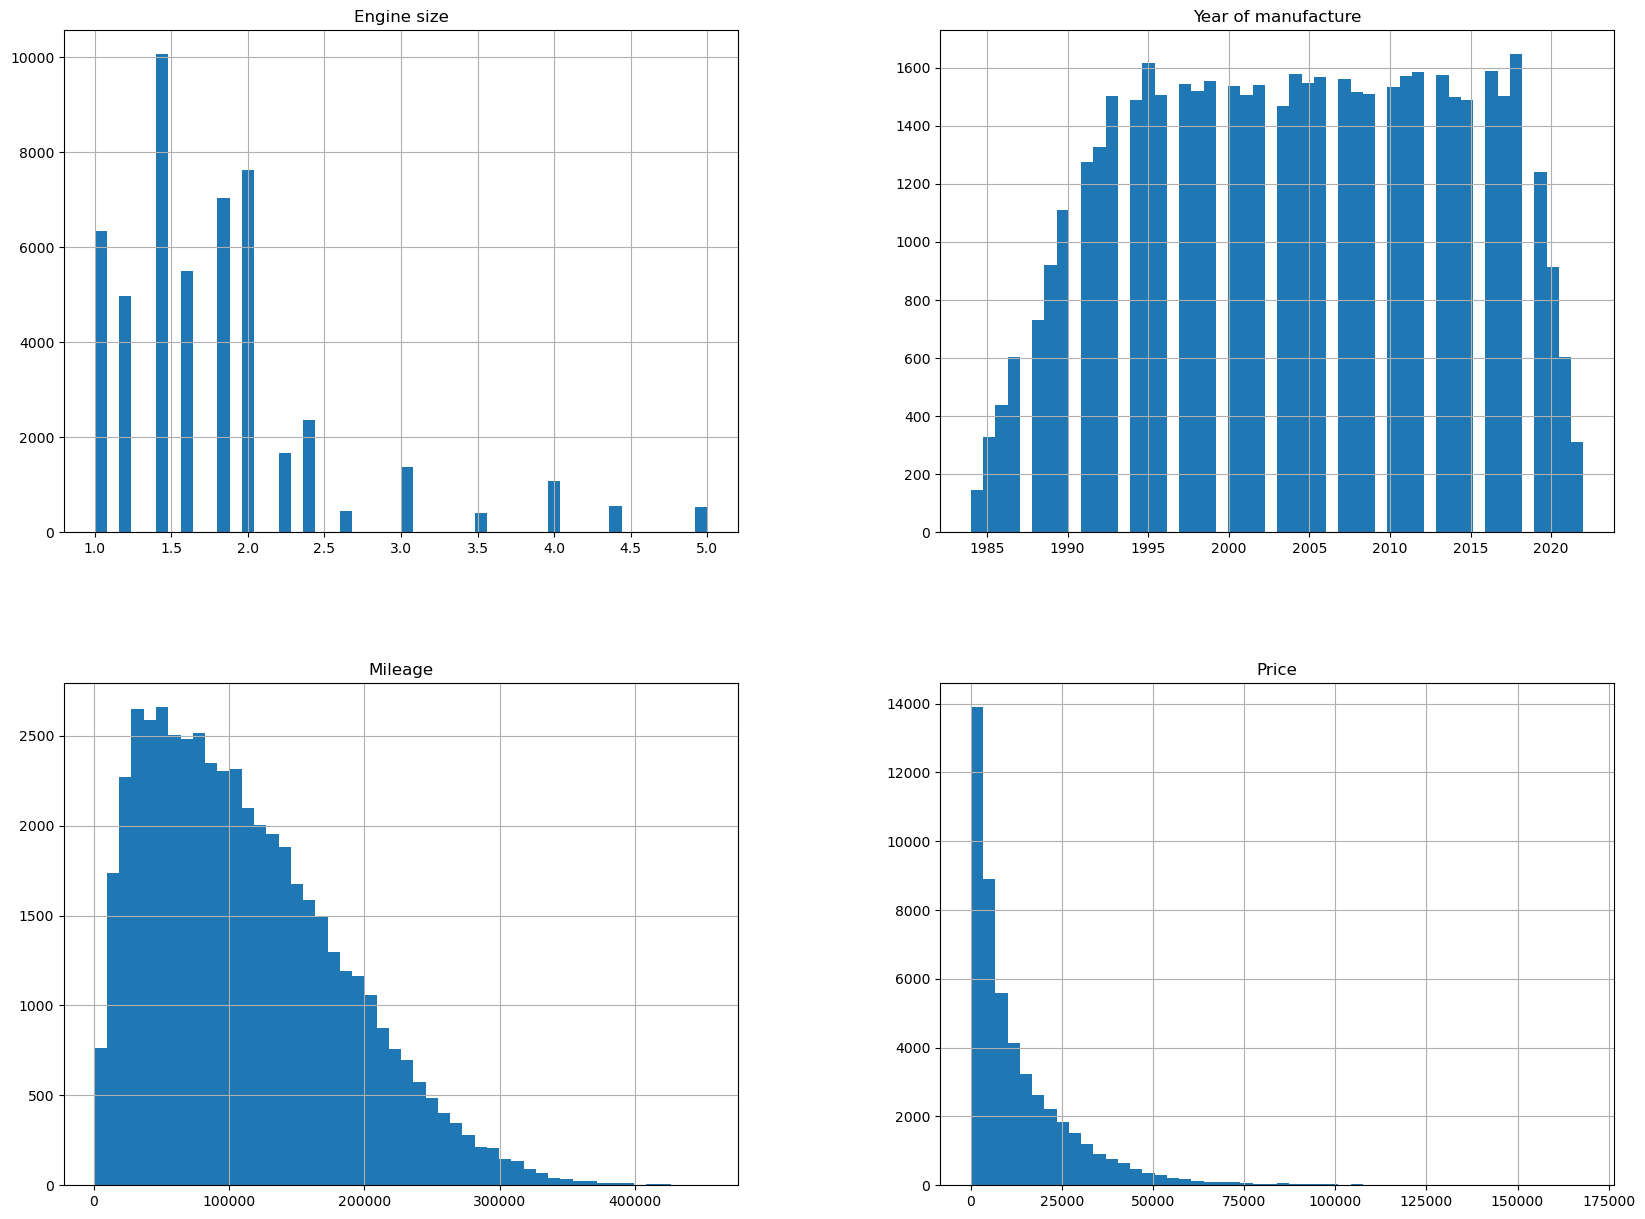

In [12]:
# plot a histogram for each numerical attribute
df.hist(bins=50, figsize=(20,15))
plt.show()


In [13]:
df.dtypes

Manufacturer            object
Model                   object
Engine size            float64
Fuel type               object
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object

In [14]:
df.columns

Index(['Manufacturer', 'Model', 'Engine size', 'Fuel type',
       'Year of manufacture', 'Mileage', 'Price'],
      dtype='object')

        Engine size  Year of manufacture        Mileage          Price
count  49988.000000         49988.000000   49988.000000   49988.000000
mean       1.773140          2004.209630  112515.561215   13829.112387
std        0.734149             9.646056   71624.341062   16417.812203
min        1.000000          1984.000000     630.000000      76.000000
25%        1.400000          1996.000000   54375.250000    3059.750000
50%        1.600000          2004.000000  101011.500000    7971.000000
75%        2.000000          2012.000000  158617.250000   19028.500000
max        5.000000          2022.000000  453537.000000  168081.000000


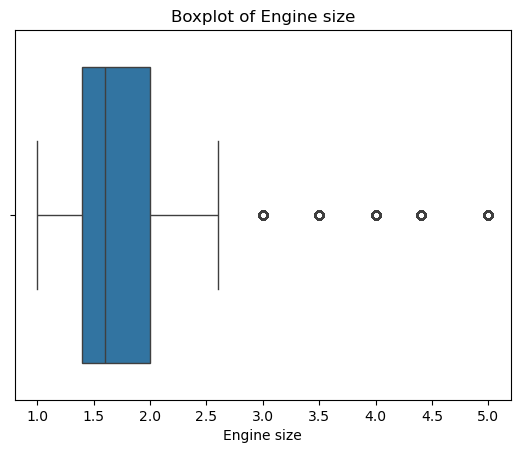

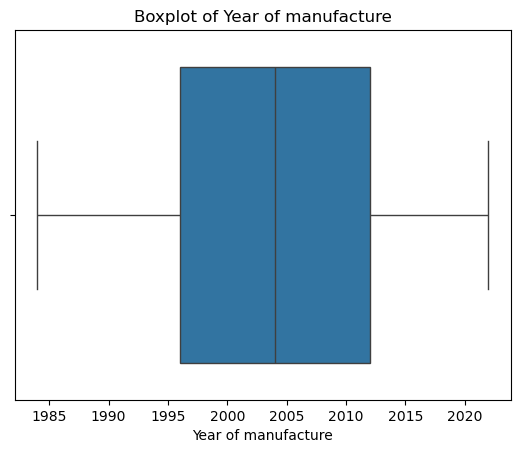

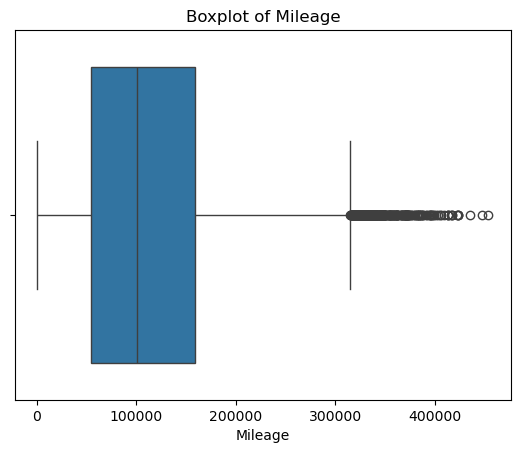

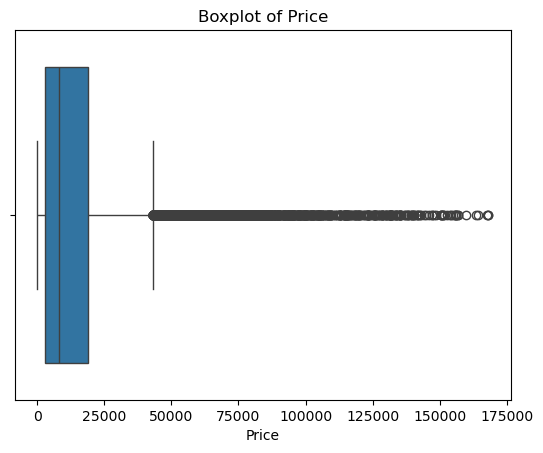

In [15]:
# Summarizing numerical columns
print(df[['Engine size','Year of manufacture', 'Mileage', 'Price']].describe())


# Visualizing boxplots for numerical columns
for col in ['Engine size','Year of manufacture', 'Mileage', 'Price']:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Looking for Correlations

In [16]:
df.dtypes

Manufacturer            object
Model                   object
Engine size            float64
Fuel type               object
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object

In [17]:
corr_matrix = df[['Engine size', 'Year of manufacture', 'Mileage', 'Price']].corr()

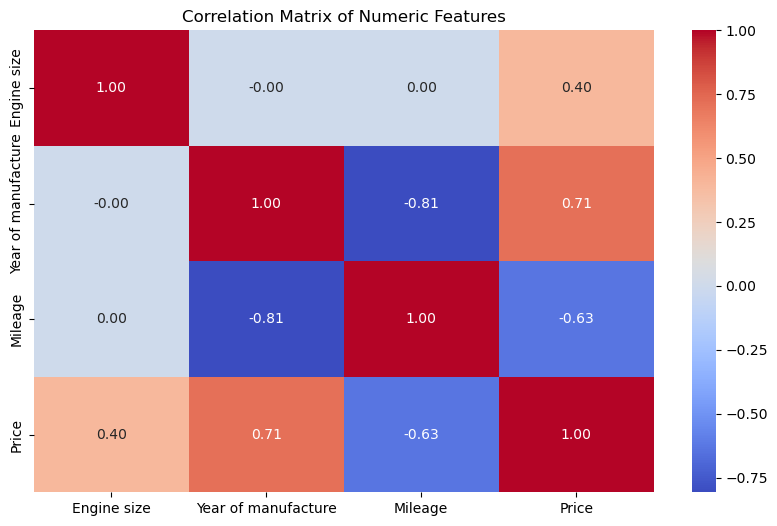

In [18]:
# Visualizing the correlation matrix using a heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

From the correlation matrix above;
- Year of manufacture has a strong direct proportionality to Prie
- Engine size is moderately directly proportional to price
- Mileage is Strongly Indirectly Proportional to the Price

In [19]:
df.head(10)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
5,Ford,Focus,1.4,Petrol,2018,33603,29204
6,Ford,Mondeo,1.8,Diesel,2010,86686,14350
7,Toyota,Prius,1.4,Hybrid,2015,30663,30297
8,VW,Polo,1.2,Petrol,2012,73470,9977
9,Ford,Focus,2.0,Diesel,1992,262514,1049


### Univariate Analysis (Quick Checks)
✔ Histograms / KDE plots for:
- Price
- Mileage
- Year of manufacture
- Engine size

# Data Preprocessing

✅ 1. Essential Feature Engineering for Car Price Prediction

- Car Age (instead of using Year directly)
`df['Car_Age'] = current_year - df['Year of manufacture']`

- Mileage per Year (Usage Intensity). i.e A car with 150,000 km over 15 years is not the same as 150,000 km over 5 years.
`df['Mileage_per_Year'] = df['Mileage'] / df['Car_Age'].replace(0, 1)`

- Engine Size Category (optional binning)
You can create bins like:
Small: <1.4
Medium: 1.4–2.0
Large: >2.0
Or just standard binning:
`df['Engine_Category'] = pd.cut(df['Engine size'], bins=[0, 1.4, 2.0, 4.0], labels=['Small','Medium','Large'])`

- Log-transform the target (Price): Car prices are usually right-skewed. Applying log transformation stabilizes variance and reduces outlier impact
`df['Log_Price'] = np.log(df['Price'])`


✅ 2. Encoding Categorical Variables Properly
Thefore the ffg encoding is prefarable;
Manufacturer → One-hot encoding is fine.
Fuel Type → One-hot encoding works.
Model → This is tricky.


✅ 3. Interaction features (often useful)
Useful examples:
Engine size × Manufacturer
Engine size × Fuel type
Car age × Mileage

✅ 4. Remove or treat extreme outliers.
Before fitting the model:
-Remove cars priced at absurdly low or high values
- Remove mileage above the 99th percentile
- Remove cars older than 30 years if they skew the model

eg: Your dataset has a 1988 Toyota — that’s essentially a classic/vintage category and will distort the model.